## Play a game

In [62]:
from darts.game import Leg

In [63]:
leg = Leg(players=['Mikey', 'Sian'])

In [64]:
leg

Mikey:   501
 Sian:   501

In [65]:
leg.turn('Mikey', ['20', 'D7', '2'])

In [66]:
leg

Mikey:   501  465
 Sian:   501

## Aiming for a particular score

Goal: Suppose I have a particular throwing distribution, with variance matrix $\Sigma$. I want to score exactly $N$ points on the next throw, by hitting a specific segment of the board (including doubles/triples/bulls). For each segment, which point should I aim for to maximise the probability of getting the right score?

In [128]:
board

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [129]:
i, j = 100, 100

In [130]:
from darts.stats import gaussian_filter

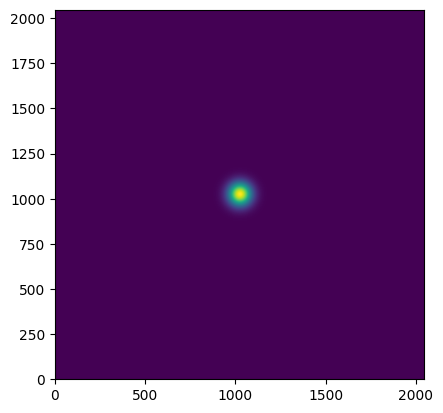

In [138]:
plt.imshow(gaussian_filter(board, (0, 0), 100*Sigma), origin='lower')

In [288]:
gf = gaussian_filter(board, (0, 0), 100*Sigma)
gf = gf / np.sum(gf)

In [289]:
sum(sum(np.where(board == 25, gf, 0)))

0.5348848794092322

In [340]:
from skimage.feature import peak_local_max

In [345]:
allowed_scores = [1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,
        16, 17, 18, 19, 20, 21, 22, 24, 25, 26, 27, 28, 30, 32, 33, 34,
        36, 38, 39, 40, 42, 45, 48, 50, 51, 54, 57, 60]

In [346]:
probs = {}
for allowed_score in tqdm(allowed_scores):
    indicator = np.where(board == allowed_score, 1, 0)
    board_ft = np.fft.fft2(indicator)
    filter_ft = np.fft.fft2(np.fft.ifftshift(gf))
    prod_ft = board_ft * filter_ft
    acc = np.real(np.fft.ifft2(prod_ft))
    xy = peak_local_max(acc, min_distance=2, threshold_abs=1e-10)
    for i, j in xy:
        probs[(i, j)] = acc[i, j]

100%|██████████████████████████████████████████████████████████████████████████████████| 43/43 [01:08<00:00,  1.60s/it]


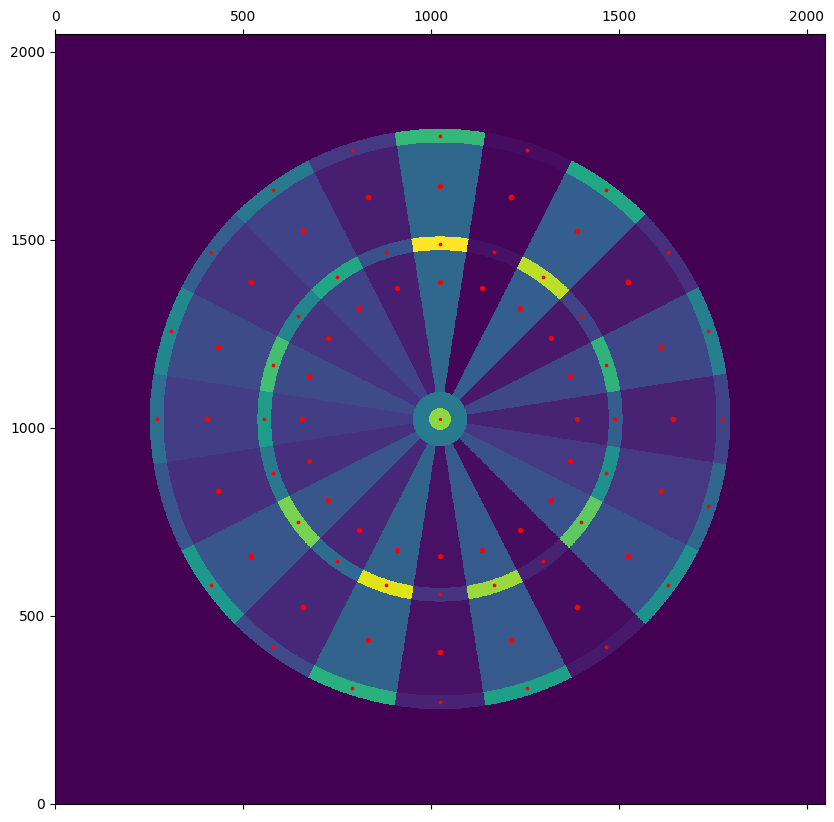

In [349]:
fig, ax = plt.subplots(figsize=(10, 10))
ax.matshow(board, origin='lower')
for (i, j), p in probs.items():
    ax.scatter(j, i, color='red', s=10*p)

## Strategy

Suppose I have the score $N$, and want to check out in the next $D$ darts. Assuming I am at the points in each segment described in the previous section, where should I aim? 

https://www.tandfonline.com/doi/abs/10.1080/01605682.2019.1610341

https://arxiv.org/pdf/2011.11031.pdf